In [1]:
import requests
import torch
import torch.nn as nn
from pytorch_grad_cam import EigenCAM
import torchvision.models as models
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gc
import cv2
import os
import sys
from torch.utils.data import DataLoader

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))
from util.PNGDatasetNormalized import PNGFolderDataset

# Prediction Model Setup

In [2]:
# ------------------------------------------------------------------
# AI MODEL CONFIGURATION
# ------------------------------------------------------------------
device = "cuda" if torch.cuda.is_available() else "cpu"

model_registry = {
    "Atelectasis": "/home/varrel/image_model_dict/final/fixed_swinb_atelectasis_model_epoch6.pth",
    "Cardiomegaly": "/home/varrel/image_model_dict/final/fixed_swinb_cardiomegaly_model_epoch5.pth",
    "Consolidation": "/home/varrel/image_model_dict/final/fixed_swinb_consolidation_model_epoch4.pth",
    "Edema": "/home/varrel/image_model_dict/final/fixed_swinb_edema_model_epoch4.pth",
    "Enlarged Cardiomediastinum": "/home/varrel/image_model_dict/final/fixed_swinb_enlarged_model_epoch7.pth",
    "Fracture": "/home/varrel/image_model_dict/final/fixed_swinb_fracture_model_epoch1.pth",
    "Lung Lesion": "/home/varrel/image_model_dict/final/fixed_swinb_lesion_model_epoch3.pth",
    "Lung Opacity": "/home/varrel/image_model_dict/final/fixed_swinb_opacity_model_epoch7.pth",
    "Pleural Effusion": "/home/varrel/image_model_dict/final/fixed_swinb_effusion_model_epoch5.pth",
    "Pneumonia": "/home/varrel/image_model_dict/final/fixed_swinb_pneumonia_model_epoch2.pth",
    "Pneumothorax": "/home/varrel/image_model_dict/final/fixed_swinb_pneumothorax_model_epoch9.pth",
    "Support Device": "/home/varrel/image_model_dict/final/fixed_swinb_supportdevice_model_epoch6.pth"
}

In [ ]:
# ------------------------------------------------------------------
# HELPER FUNCTIONS
# ------------------------------------------------------------------
def safe_collate(batch):
    batch = [b for b in batch if b is not None]
    imgs, labs, idxs = [], [], []
    for b in batch:
        img = torch.tensor(b["img"])
        lab = torch.tensor(b["lab"])
        # Ensure 3-channel
        if img.ndim == 3 and img.shape[0] == 1: img = img.repeat(3, 1, 1)
        elif img.ndim == 2: img = img.unsqueeze(0).repeat(3, 1, 1)
        imgs.append(img)
        labs.append(lab)
        idxs.append(b["idx"])
    return {"img": torch.stack(imgs), "lab": torch.stack(labs), "idx": idxs}

def run_inference(model, loader):
    all_probs = []
    all_preds = []
    all_labels = []

    model.eval()
    
    with torch.no_grad():
        for batch in loader: 
            inputs = batch["img"].to(device)
            if "lab" in batch:
                labels = batch["lab"].cpu().numpy()
                labels = np.nan_to_num(labels, nan=0.0).astype(int)
            else:
                labels = np.zeros(len(inputs))

            outputs = model(inputs).squeeze(1)
            outputs = torch.clamp(outputs, min=-20, max=20)
            probs = torch.sigmoid(outputs).cpu().numpy()
            
            preds = (probs > 0.5).astype(int)

            all_probs.extend(probs)
            all_preds.extend(preds)
            all_labels.extend(labels)

    all_probs = np.array(all_probs)
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    return all_probs, all_preds, all_labels


def load_single_model(model_path):
    """Loads a single Swin-B model architecture and weights."""
    weights = models.Swin_B_Weights.IMAGENET1K_V1
    model = models.swin_b(weights=weights)
    in_features = model.head.in_features
    model.head = nn.Linear(in_features, 1)
    
    checkpoint = torch.load(model_path, map_location='cpu', weights_only=False)
    
    if 'model_state_dict' in checkpoint:
        model.load_state_dict(checkpoint['model_state_dict'])
    else:
        model.load_state_dict(checkpoint)
    
    model.to(device)
    model.eval()
    return model

def run_sequential_inference(loader, model_registry):
    """
    Runs your inference function 12 times (once per pathology).
    Returns a dictionary: { 'Atelectasis': [prob_img1, prob_img2...], ... }
    """
    aggregated_results = {}
    
    print(f"Starting sequential inference on {len(loader.dataset)} image(s)...")

    for pathology, path in model_registry.items():
        print(f"-> Loading {pathology}...", end=" ")
        
        # A. Load
        model = load_single_model(path)
        
        # B. Run YOUR inference function
        probs, _, _ = run_inference(model, loader)
        
        # C. Store Results
        aggregated_results[pathology] = probs
        print(f"Done. (Max Prob: {probs.max():.4f})")
        
        # D. Unload to save memory
        del model
        torch.cuda.empty_cache()
        gc.collect()

    return aggregated_results

def get_localization_label(heatmap):
    """Maps heatmap peak to anatomical location."""
    if heatmap is None or np.max(heatmap) == 0:
        return "unspecified location"
    
    idx = np.argmax(heatmap)
    y, x = np.unravel_index(idx, heatmap.shape)
    h, w = heatmap.shape
    
    # Image Left = Patient Right
    side = "right" if x < w / 2 else "left"
    
    if y < h / 3: zone = "upper lung zone"
    elif y < (2 * h / 3): zone = "middle lung zone"
    else: zone = "lower lung zone"
        
    return f"the {side} {zone}"

def swin_reshape_transform(tensor):
    """Adjusts Swin-B output (B,H,W,C) -> (B,C,H,W) for CAM."""
    if tensor.ndim == 4:
        return tensor.permute(0, 3, 1, 2)
    return tensor

def generate_cam_from_tensor(model, input_tensor, img_norm_for_mask):
    """
    Generates CAM using the pre-processed input_tensor directly.
    """
    # 1. Initialize EigenCAM with Swin-specific transform
    cam = EigenCAM(
        model=model, 
        target_layers=[model.norm], 
        reshape_transform=swin_reshape_transform
    )
    
    # 2. Generate raw CAM
    grayscale_cam = cam(input_tensor=input_tensor)[0, :]
    
    # 3. Create Mask (to remove background noise)
    # Convert normalized image to uint8 for thresholding
    norm_image_uint8 = (img_norm_for_mask * 255).astype(np.uint8)
    # Use simple thresholding to find the body/lungs
    _, binary_mask = cv2.threshold(norm_image_uint8, 15, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(binary_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if contours:
        largest_contour = max(contours, key=cv2.contourArea)
        filled_mask = np.zeros_like(binary_mask)
        cv2.drawContours(filled_mask, [largest_contour], -1, 255, thickness=cv2.FILLED)
        mask = filled_mask.astype(np.float32) / 255.0
    else:
        mask = np.ones_like(img_norm_for_mask[:,:,0]) # Fallback

    # 4. Apply Mask
    masked_cam = grayscale_cam * mask
    masked_cam = masked_cam - masked_cam.min()
    if masked_cam.max() > 0:
        masked_cam = masked_cam / masked_cam.max()
        
    return masked_cam

# Data & Image Loader

### Label & Image Load

In [4]:
pc_png_selection = PNGFolderDataset(
    img_dir="/home/varrel/imaging/all_images/PC_dataset/images_all/preprocess7",
    csv_path="/home/varrel/GitHub/CXR-Analysis/final_csv/pc_selection_split_filtered.csv", 
    id_col="ImageID"
)
sample = pc_png_selection[7728]
img_data = sample["img"]

if isinstance(img_data, np.ndarray):
    img_data = torch.from_numpy(img_data)

if img_data.ndim == 2:
    input_tensor = img_data.unsqueeze(0).unsqueeze(0) # (1, 1, H, W)
elif img_data.ndim == 3:
    input_tensor = img_data.unsqueeze(0) # (1, C, H, W)

if input_tensor.shape[1] == 1:
    input_tensor = input_tensor.repeat(1, 3, 1, 1)

input_tensor = input_tensor.to(device)
print(f"Corrected Tensor Shape: {input_tensor.shape}")

inference_loader = DataLoader([sample], batch_size=1, shuffle=False, collate_fn=safe_collate)

Corrected Tensor Shape: torch.Size([1, 3, 224, 224])


In [5]:
index = pc_png_selection.csv.index[pc_png_selection.csv['ImageID'] == '216840111366964013590140476722013025090520051_02-008-114']
index

Index([7728], dtype='int64')

In [6]:
# Real Label
print(pc_png_selection.pathologies)
print(sample["lab"])

['No Finding', 'Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Enlarged Cardio.', 'Fracture', 'Lung Lesion', 'Lung Opacity', 'Pleural Effusion', 'Pneumonia', 'Pneumothorax', 'Support Devices']
[0. 1. 0. 0. 1. 0. 0. 0. 1. 1. 1. 0. 1.]


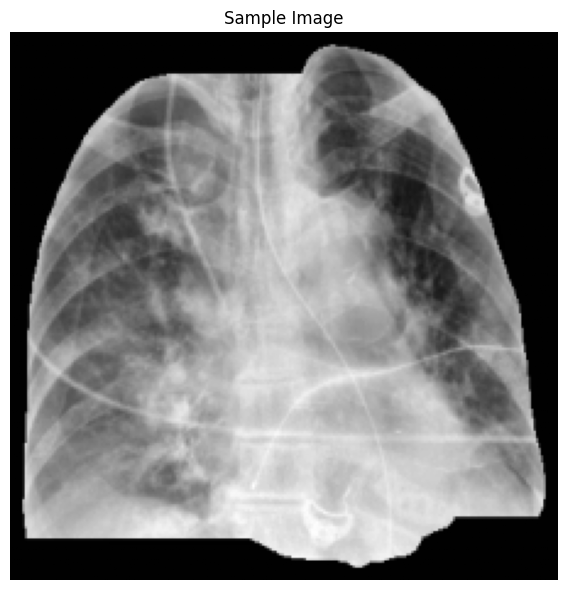

In [7]:
# Real Image
img_data = sample["img"]

if hasattr(img_data, 'numpy'):
    img_data = img_data.numpy()
if img_data.ndim == 3 and img_data.shape[0] == 1:
    img_data = img_data.squeeze(0)

plt.figure(figsize=(6, 6))
plt.imshow(img_data, cmap='gray')
plt.title(f"Sample Image")
plt.axis('off')
plt.tight_layout()
plt.savefig("sample_image.png", dpi=300)
plt.show()

### Model Prediction

In [8]:
results_dict = run_sequential_inference(inference_loader, model_registry)
    
print("\n--- SwinB Output (Input for LLM) ---")
llm_input = {k: v[0] for k, v in results_dict.items()}
for k, v in llm_input.items():
    print(f"'{k}': {v:.4f}")

Starting sequential inference on 1 image(s)...
-> Loading Atelectasis... Done. (Max Prob: 0.5814)
-> Loading Cardiomegaly... Done. (Max Prob: 0.1366)
-> Loading Consolidation... Done. (Max Prob: 0.0987)
-> Loading Edema... Done. (Max Prob: 0.0679)
-> Loading Enlarged Cardiomediastinum... Done. (Max Prob: 0.0349)
-> Loading Fracture... Done. (Max Prob: 0.0563)
-> Loading Lung Lesion... Done. (Max Prob: 0.0057)
-> Loading Lung Opacity... Done. (Max Prob: 0.5514)
-> Loading Pleural Effusion... Done. (Max Prob: 0.9221)
-> Loading Pneumonia... Done. (Max Prob: 0.2155)
-> Loading Pneumothorax... Done. (Max Prob: 0.0233)
-> Loading Support Device... Done. (Max Prob: 0.8987)

--- SwinB Output (Input for LLM) ---
'Atelectasis': 0.5814
'Cardiomegaly': 0.1366
'Consolidation': 0.0987
'Edema': 0.0679
'Enlarged Cardiomediastinum': 0.0349
'Fracture': 0.0563
'Lung Lesion': 0.0057
'Lung Opacity': 0.5514
'Pleural Effusion': 0.9221
'Pneumonia': 0.2155
'Pneumothorax': 0.0233
'Support Device': 0.8987


# Report Generation

## gpt-oss:20b

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

#------------------------------------------------------------------
# TRESHOLD HANDLING
#------------------------------------------------------------------
thresholds = {
    "Atelectasis": 0.568, "Cardiomegaly": 0.587, "Consolidation": 0.760,
    "Edema": 0.659, "Enlarged Cardiomediastinum": 0.757, "Fracture": 0.747,
    "Lung Lesion": 0.213, "Lung Opacity": 0.530, "Pleural Effusion": 0.590,
    "Pneumonia": 0.514, "Pneumothorax": 0.101, "Support Device": 0.395
}

model_paths = {
    "Pneumonia": "/home/varrel/image_model_dict/final/fixed_swinb_pneumonia_model_epoch2.pth",
    "Lung Opacity": "/home/varrel/image_model_dict/final/fixed_swinb_opacity_model_epoch7.pth",
    "Lung Lesion": "/home/varrel/image_model_dict/final/fixed_swinb_lesion_model_epoch3.pth"
}

findings_with_location = []
saved_heatmaps = {}
buffer = 0.05

print(f"Processing Image ID: 1281")
img_vis = input_tensor[0, 0, :, :].cpu().numpy()
img_norm = (img_vis - img_vis.min()) / (img_vis.max() - img_vis.min())
img_norm_for_mask = np.expand_dims(img_norm, axis=2)

for pathology, threshold in thresholds.items():
    score = results_dict.get(pathology, [0.0])[0]
    
    # 1. Determine Clinical Status
    if score > (threshold + buffer):
        status = "Positive"
    elif score >= (threshold - buffer):
        status = "Possible"
    else:
        status = "Negative"
        
    # 2. Localization Logic
    if status in ["Positive", "Possible"] and pathology in model_paths:
        print(f"   -> Localizing {pathology}...")
        
        # A. Initialize Model Structure
        weights = models.Swin_B_Weights.IMAGENET1K_V1
        model = models.swin_b(weights=weights)
        model.head = nn.Linear(model.head.in_features, 1)
        
        # B. Load Specific Weights
        checkpoint = torch.load(model_paths[pathology], map_location='cpu', weights_only=False)
        if 'model_state_dict' in checkpoint:
            model.load_state_dict(checkpoint['model_state_dict'])
        else:
            model.load_state_dict(checkpoint)
            
        model.to(device)
        model.eval()
        
        # C. Generate CAM using pre-processed tensor
        heatmap = generate_cam_from_tensor(model, input_tensor, img_norm)
        loc = get_localization_label(heatmap)
        saved_heatmaps[pathology] = heatmap
        
        findings_with_location.append(f"- {pathology}: {status} at {loc}")
        
        # Cleanup
        del model
        torch.cuda.empty_cache()

    elif status == "Negative":
        findings_with_location.append(f"- {pathology}: Negative")
    else:
        # Positive but no localization needed (e.g. Cardiomegaly)
        findings_with_location.append(f"- {pathology}: {status}")

# --- REPORT GENERATION ---
final_context_string = "\n".join(findings_with_location)

my_model = "gpt-oss:20b"

# ------------------------------------------------------------------
# PROMPTING STRATEGY
# ------------------------------------------------------------------

# 1. System Prompt: The Persona and Strict Rules
system_prompt = """You are an expert Radiologist Assistant. 
Your task is to write a high-quality 'IMPRESSION' section for a Chest X-ray report.

### CRITICAL RULES (ANTI-HALLUCINATION):
1. **Facts Only:** You must write strictly based on the [PATIENT FINDINGS] provided.
2. **Localization:** If a finding has a location (e.g., "at the right lower lung zone"), you MUST include it. If no location is listed, do NOT invent one.
3. **Devices:** Do not mention tubes, lines, or catheters unless 'Support Device' is listed as Positive.
4. **Negatives:** Group all negative findings into one concise sentence at the end (e.g., "No pneumothorax or pleural effusion.").

### STYLE GUIDE (MIMIC-CXR):
- Use professional, objective language.
- Avoid robotic lists. Combine related concepts (e.g., "Lung volumes are low with retrocardiac opacity").
"""

# 2. User Prompt: The Data + The Examples (Few-Shot)
user_prompt = f"""
[PATIENT FINDINGS]
{final_context_string}

[STYLE EXAMPLES - LEARN THE TONE, DO NOT COPY THE CONTENT]

Example 1:
"Mild cardiomegaly is present. Mild pulmonary edema has minimally improved. Right lower lobe opacity is a combination of small effusion and atelectasis. No pneumothorax."

Example 2:
"Leftward mediastinal shift indicates consolidation in the left lower lobe. Small left pleural effusion is presumed. Vascular congestion and perihilar opacification in the right lung is suggestive of edema."

Example 3:
"Collapse of the right upper lobe is accompanied by mediastinal fullness. Interstitial abnormality is explained by congestive heart failure. Heart size is top-normal."

[YOUR TASK]
Write the IMPRESSION for the patient based *only* on the [PATIENT FINDINGS] above. 
Use the style of the examples (flowing sentences, professional vocabulary) but strictly adhere to the facts provided.

IMPRESSION:"""

# ------------------------------------------------------------------
# INFERENCE
# ------------------------------------------------------------------
try:
    final_first_response_gpt = requests.post(
        'http://127.0.0.1:11434/api/chat',
        json={
            "model": my_model,
            "messages": [
                {"role": "system", "content": system_prompt},
                {"role": "user", "content": user_prompt}
            ],
            "stream": False,
            "seed": 42,
            "temperature": 0.1, 
            "top_p": 0.9,
            "num_predict": 512
        }
    )
    
    if final_first_response_gpt.status_code == 200:
        print("\n--- Generated MIMIC-Style Report ---")
        report_text = final_first_response_gpt.json()['message']['content']
        print(report_text)
    else:
        print(f"Error: {final_first_response_gpt.status_code} - {final_first_response_gpt.text}")

except Exception as e:
    print(f"Connection failed: {e}")

Processing Image ID: 1281
   -> Localizing Lung Opacity...

--- Generated MIMIC-Style Report ---
IMPRESSION:  
Left‑mid lung zone opacity is present with possible atelectasis. A small pleural effusion is seen. A support device is noted. No cardiomegaly, consolidation, edema, enlarged cardiomediastinum, fracture, lung lesion, pneumonia, or pneumothorax.



--- Visualizing EigenCAM Heatmaps ---


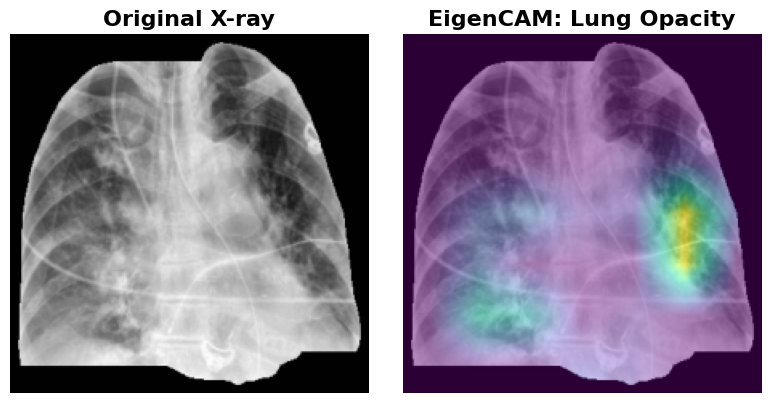

In [55]:
import matplotlib.pyplot as plt
from pytorch_grad_cam.utils.image import show_cam_on_image
import cv2

# Only plot if we actually generated heatmaps
if saved_heatmaps:
    print("\n--- Visualizing EigenCAM Heatmaps ---")
    
    # 1. Prepare the base image for the overlay
    base_img_vis = input_tensor[0, 0, :, :].cpu().numpy() 
    base_img_norm = (base_img_vis - base_img_vis.min()) / (base_img_vis.max() - base_img_vis.min())
    rgb_img = np.stack([base_img_norm]*3, axis=-1)

    # 2. Setup the Matplotlib figure
    num_plots = 1 + len(saved_heatmaps)
    fig, axes = plt.subplots(1, num_plots, figsize=(4 * num_plots, 4))
    
    if num_plots == 1:
        axes = [axes]

    # 3. Plot Original Image
    axes[0].imshow(rgb_img)
    axes[0].set_title("Original X-ray", fontsize=16, weight='bold')
    axes[0].axis('off')

    # 4. Plot each saved heatmap
    for i, (pathology_name, hmap) in enumerate(saved_heatmaps.items(), start=1):

        # --- VIRIDIS COLORMAP ADDED HERE ---
        cam_overlay = show_cam_on_image(
            rgb_img, 
            hmap, 
            use_rgb=True, 
            colormap=cv2.COLORMAP_VIRIDIS
        )
        axes[i].imshow(cam_overlay)
        axes[i].set_title(f"EigenCAM: {pathology_name}", fontsize=16, weight='bold')
        axes[i].axis('off')

        plt.tight_layout()
        plt.savefig("eigencam_visualization.png", dpi=300, bbox_inches='tight')
        plt.show()
        
else:
    print("\nNo focal pathologies required localization for this image.")

## qwen3:32b

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

#------------------------------------------------------------------
# TRESHOLD HANDLING
#------------------------------------------------------------------
thresholds = {
    "Atelectasis": 0.568, "Cardiomegaly": 0.587, "Consolidation": 0.760,
    "Edema": 0.659, "Enlarged Cardiomediastinum": 0.757, "Fracture": 0.747,
    "Lung Lesion": 0.213, "Lung Opacity": 0.530, "Pleural Effusion": 0.590,
    "Pneumonia": 0.514, "Pneumothorax": 0.101, "Support Device": 0.395
}

model_paths = {
    "Pneumonia": "/home/varrel/image_model_dict/final/fixed_swinb_pneumonia_model_epoch2.pth",
    "Lung Opacity": "/home/varrel/image_model_dict/final/fixed_swinb_opacity_model_epoch7.pth",
    "Lung Lesion": "/home/varrel/image_model_dict/final/fixed_swinb_lesion_model_epoch3.pth"
}

findings_with_location = []
saved_heatmaps = {}
buffer = 0.05

print(f"Processing Image ID: 1281")
img_vis = input_tensor[0, 0, :, :].cpu().numpy()
img_norm = (img_vis - img_vis.min()) / (img_vis.max() - img_vis.min())
img_norm_for_mask = np.expand_dims(img_norm, axis=2)

for pathology, threshold in thresholds.items():
    score = results_dict.get(pathology, [0.0])[0]
    
    # 1. Determine Clinical Status
    if score > (threshold + buffer):
        status = "Positive"
    elif score >= (threshold - buffer):
        status = "Possible"
    else:
        status = "Negative"
        
    # 2. Localization Logic
    if status in ["Positive", "Possible"] and pathology in model_paths:
        print(f"   -> Localizing {pathology}...")
        
        # A. Initialize Model Structure
        weights = models.Swin_B_Weights.IMAGENET1K_V1
        model = models.swin_b(weights=weights)
        model.head = nn.Linear(model.head.in_features, 1)
        
        # B. Load Specific Weights
        checkpoint = torch.load(model_paths[pathology], map_location='cpu', weights_only=False)
        if 'model_state_dict' in checkpoint:
            model.load_state_dict(checkpoint['model_state_dict'])
        else:
            model.load_state_dict(checkpoint)
            
        model.to(device)
        model.eval()
        
        # C. Generate CAM using pre-processed tensor
        heatmap = generate_cam_from_tensor(model, input_tensor, img_norm)
        loc = get_localization_label(heatmap)
        saved_heatmaps[pathology] = heatmap
        
        findings_with_location.append(f"- {pathology}: {status} at {loc}")
        
        # Cleanup
        del model
        torch.cuda.empty_cache()

    elif status == "Negative":
        findings_with_location.append(f"- {pathology}: Negative")
    else:
        # Positive but no localization needed (e.g. Cardiomegaly)
        findings_with_location.append(f"- {pathology}: {status}")

# --- REPORT GENERATION ---
final_context_string = "\n".join(findings_with_location)

my_model = "qwen3:32b"

# ------------------------------------------------------------------
# PROMPTING STRATEGY
# ------------------------------------------------------------------

# 1. System Prompt: The Persona and Strict Rules
system_prompt = """You are an expert Radiologist Assistant. 
Your task is to write a high-quality 'IMPRESSION' section for a Chest X-ray report.

### CRITICAL RULES (ANTI-HALLUCINATION):
1. **Facts Only:** You must write strictly based on the [PATIENT FINDINGS] provided.
2. **Localization:** If a finding has a location (e.g., "at the right lower lung zone"), you MUST include it. If no location is listed, do NOT invent one.
3. **Devices:** Do not mention tubes, lines, or catheters unless 'Support Device' is listed as Positive.
4. **Negatives:** Group all negative findings into one concise sentence at the end (e.g., "No pneumothorax or pleural effusion.").

### STYLE GUIDE (MIMIC-CXR):
- Use professional, objective language.
- Avoid robotic lists. Combine related concepts (e.g., "Lung volumes are low with retrocardiac opacity").
"""

# 2. User Prompt: The Data + The Examples (Few-Shot)
user_prompt = f"""
[PATIENT FINDINGS]
{final_context_string}

[STYLE EXAMPLES - LEARN THE TONE, DO NOT COPY THE CONTENT]

Example 1:
"Mild cardiomegaly is present. Mild pulmonary edema has minimally improved. Right lower lobe opacity is a combination of small effusion and atelectasis. No pneumothorax."

Example 2:
"Leftward mediastinal shift indicates consolidation in the left lower lobe. Small left pleural effusion is presumed. Vascular congestion and perihilar opacification in the right lung is suggestive of edema."

Example 3:
"Collapse of the right upper lobe is accompanied by mediastinal fullness. Interstitial abnormality is explained by congestive heart failure. Heart size is top-normal."

[YOUR TASK]
Write the IMPRESSION for the patient based *only* on the [PATIENT FINDINGS] above. 
Use the style of the examples (flowing sentences, professional vocabulary) but strictly adhere to the facts provided.

IMPRESSION:"""

# ------------------------------------------------------------------
# INFERENCE
# ------------------------------------------------------------------
try:
    final_first_response_gpt = requests.post(
        'http://127.0.0.1:11434/api/chat',
        json={
            "model": my_model,
            "messages": [
                {"role": "system", "content": system_prompt},
                {"role": "user", "content": user_prompt}
            ],
            "stream": False,
            "seed": 42,
            "temperature": 0.1, 
            "top_p": 0.9,
            "num_predict": 512
        }
    )
    
    if final_first_response_gpt.status_code == 200:
        print("\n--- Generated MIMIC-Style Report ---")
        report_text = final_first_response_gpt.json()['message']['content']
        print(report_text)
    else:
        print(f"Error: {final_first_response_gpt.status_code} - {final_first_response_gpt.text}")

except Exception as e:
    print(f"Connection failed: {e}")

Processing Image ID: 1281
   -> Localizing Lung Opacity...

--- Generated MIMIC-Style Report ---
IMPRESSION: Left pleural effusion is present with a possible opacity in the left middle lung zone, suggestive of atelectasis. A support device is in place. No cardiomegaly, consolidation, edema, enlarged cardiomediastinum, fracture, lung lesion, pneumonia, or pneumothorax.


## deepseek-r1:32b

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

#------------------------------------------------------------------
# TRESHOLD HANDLING
#------------------------------------------------------------------
thresholds = {
    "Atelectasis": 0.568, "Cardiomegaly": 0.587, "Consolidation": 0.760,
    "Edema": 0.659, "Enlarged Cardiomediastinum": 0.757, "Fracture": 0.747,
    "Lung Lesion": 0.213, "Lung Opacity": 0.530, "Pleural Effusion": 0.590,
    "Pneumonia": 0.514, "Pneumothorax": 0.101, "Support Device": 0.395
}

model_paths = {
    "Pneumonia": "/home/varrel/image_model_dict/final/fixed_swinb_pneumonia_model_epoch2.pth",
    "Lung Opacity": "/home/varrel/image_model_dict/final/fixed_swinb_opacity_model_epoch7.pth",
    "Lung Lesion": "/home/varrel/image_model_dict/final/fixed_swinb_lesion_model_epoch3.pth"
}

findings_with_location = []
saved_heatmaps = {}
buffer = 0.05

print(f"Processing Image ID: 1281")
img_vis = input_tensor[0, 0, :, :].cpu().numpy()
img_norm = (img_vis - img_vis.min()) / (img_vis.max() - img_vis.min())
img_norm_for_mask = np.expand_dims(img_norm, axis=2)

for pathology, threshold in thresholds.items():
    score = results_dict.get(pathology, [0.0])[0]
    
    # 1. Determine Clinical Status
    if score > (threshold + buffer):
        status = "Positive"
    elif score >= (threshold - buffer):
        status = "Possible"
    else:
        status = "Negative"
        
    # 2. Localization Logic
    if status in ["Positive", "Possible"] and pathology in model_paths:
        print(f"   -> Localizing {pathology}...")
        
        # A. Initialize Model Structure
        weights = models.Swin_B_Weights.IMAGENET1K_V1
        model = models.swin_b(weights=weights)
        model.head = nn.Linear(model.head.in_features, 1)
        
        # B. Load Specific Weights
        checkpoint = torch.load(model_paths[pathology], map_location='cpu', weights_only=False)
        if 'model_state_dict' in checkpoint:
            model.load_state_dict(checkpoint['model_state_dict'])
        else:
            model.load_state_dict(checkpoint)
            
        model.to(device)
        model.eval()
        
        # C. Generate CAM using pre-processed tensor
        heatmap = generate_cam_from_tensor(model, input_tensor, img_norm)
        loc = get_localization_label(heatmap)
        saved_heatmaps[pathology] = heatmap
        
        findings_with_location.append(f"- {pathology}: {status} at {loc}")
        
        # Cleanup
        del model
        torch.cuda.empty_cache()

    elif status == "Negative":
        findings_with_location.append(f"- {pathology}: Negative")
    else:
        # Positive but no localization needed (e.g. Cardiomegaly)
        findings_with_location.append(f"- {pathology}: {status}")

# --- REPORT GENERATION ---
final_context_string = "\n".join(findings_with_location)

my_model = "deepseek-r1:32b"

# ------------------------------------------------------------------
# PROMPTING STRATEGY
# ------------------------------------------------------------------

# 1. System Prompt: The Persona and Strict Rules
system_prompt = """You are an expert Radiologist Assistant. 
Your task is to write a high-quality 'IMPRESSION' section for a Chest X-ray report.

### CRITICAL RULES (ANTI-HALLUCINATION):
1. **Facts Only:** You must write strictly based on the [PATIENT FINDINGS] provided.
2. **Localization:** If a finding has a location (e.g., "at the right lower lung zone"), you MUST include it. If no location is listed, do NOT invent one.
3. **Devices:** Do not mention tubes, lines, or catheters unless 'Support Device' is listed as Positive.
4. **Negatives:** Group all negative findings into one concise sentence at the end (e.g., "No pneumothorax or pleural effusion.").

### STYLE GUIDE (MIMIC-CXR):
- Use professional, objective language.
- Avoid robotic lists. Combine related concepts (e.g., "Lung volumes are low with retrocardiac opacity").
"""

# 2. User Prompt: The Data + The Examples (Few-Shot)
user_prompt = f"""
[PATIENT FINDINGS]
{final_context_string}

[STYLE EXAMPLES - LEARN THE TONE, DO NOT COPY THE CONTENT]

Example 1:
"Mild cardiomegaly is present. Mild pulmonary edema has minimally improved. Right lower lobe opacity is a combination of small effusion and atelectasis. No pneumothorax."

Example 2:
"Leftward mediastinal shift indicates consolidation in the left lower lobe. Small left pleural effusion is presumed. Vascular congestion and perihilar opacification in the right lung is suggestive of edema."

Example 3:
"Collapse of the right upper lobe is accompanied by mediastinal fullness. Interstitial abnormality is explained by congestive heart failure. Heart size is top-normal."

[YOUR TASK]
Write the IMPRESSION for the patient based *only* on the [PATIENT FINDINGS] above. 
Use the style of the examples (flowing sentences, professional vocabulary) but strictly adhere to the facts provided.

IMPRESSION:"""

# ------------------------------------------------------------------
# INFERENCE
# ------------------------------------------------------------------
try:
    final_first_response_gpt = requests.post(
        'http://127.0.0.1:11434/api/chat',
        json={
            "model": my_model,
            "messages": [
                {"role": "system", "content": system_prompt},
                {"role": "user", "content": user_prompt}
            ],
            "stream": False,
            "seed": 42,
            "temperature": 0.1, 
            "top_p": 0.9,
            "num_predict": 512
        }
    )
    
    if final_first_response_gpt.status_code == 200:
        print("\n--- Generated MIMIC-Style Report ---")
        report_text = final_first_response_gpt.json()['message']['content']
        print(report_text)
    else:
        print(f"Error: {final_first_response_gpt.status_code} - {final_first_response_gpt.text}")

except Exception as e:
    print(f"Connection failed: {e}")

Processing Image ID: 1281
   -> Localizing Lung Opacity...

--- Generated MIMIC-Style Report ---
IMPRESSION: A support device is present. There is a possibility of atelectasis and pleural effusion. Lung opacity is noted in the left middle lung zone. No cardiomegaly, consolidation, edema, enlarged cardiomediastinum, fracture, lung lesion, pneumonia, or pneumothorax is identified.


# Report Generation (In-Context Learning & Treshold)

In [21]:
# Finding Multi-Label Positive in MIMIC Dataset (U-Zeros)

csv_path = "/home/varrel/GitHub/CXR-Analysis/final_csv/mimic_selection_split_xrv.csv"
mimic_sheet = pd.read_csv(csv_path)

mimic_sheet = mimic_sheet.replace(-1, 0)
mimic_sheet = mimic_sheet.drop(columns=['split'])
pathology_cols = mimic_sheet.columns[2:]
mimic_sheet['total_count'] = mimic_sheet[pathology_cols].sum(axis=1) # calculate the sums of the row
top_pathologies = mimic_sheet.sort_values(by='total_count', ascending=False).head(15)
print(top_pathologies)

       subject_id  study_id  Atelectasis  Cardiomegaly  Consolidation  Edema  \
11774    14245215  53694575          0.0           1.0            0.0    1.0   
20218    17963938  53886803          0.0           1.0            1.0    0.0   
5439     11185907  59903705          0.0           1.0            1.0    0.0   
7068     11970980  50013959          1.0           0.0            1.0    1.0   
20554    18108905  55689209          1.0           1.0            0.0    1.0   
11618    14187001  51672770          1.0           1.0            1.0    1.0   
2945     19890030  52916619          1.0           1.0            0.0    1.0   
14388    15385925  54438702          1.0           0.0            0.0    1.0   
14428    15389391  51027187          1.0           0.0            0.0    1.0   
1327     13894716  56233977          1.0           1.0            0.0    1.0   
15850    15945590  52835784          1.0           0.0            1.0    1.0   
4097     10521666  57458827          1.0

In [24]:
"""
MIMIC (20867) - 8 positive labels (Atelectasis, Cardiomegaly, Edema, Enlarged Cardiomediastinum, Opacity, Effusion, SD)
Report:
 There are persistent low lung volumes.  Widened mediastinum has improved. 
 Mild cardiomegaly is stable.  Mild pulmonary edema has minimally improved. 
 Right lower lobe opacity is a combination of small effusion and atelectasis,
 unchanged from prior.  Large calcified nodule in the left lower lobe is again
 noted.  Lines and tubes are in unchanged position.

MIMIC (13536) - 7 positive labels (Atelectasis, Cardiomegaly, Consolidation, Edema, Opacity, Effusion, SD)
Report:
 Tip of the endotracheal tube is at the thoracic inlet, with the chin down.  It
 could be advanced 2 or 3 cm for more secured seating.
 
 Leftward mediastinal shift indicates consolidation in the left lower lobe is
 largely atelectasis.  New right transjugular Swan-Ganz catheter ends in the
 mid right pulmonary artery.  Feeding tube passes into the stomach and out of
 view.  Dual-channel left transjugular line ends in the upper SVC.  No
 pneumothorax.  Small left pleural effusion is presumed.  Vascular congestion
 and perihilar opacification in the right lung is probably edema, but should be
 followed carefully to exclude developing consolidation or hemorrhage.
 
 Moderate enlargement of the cardiac silhouette and distention of mediastinal
 veins, are comparable to the preoperative appearance earlier in the day.

MIMIC (1327) - 7 positive labels (Atelectasis, Cardiomegaly, Edema, Enlarged Cardiomediastinum, Lesion, Effusion, SD)
Report:
 Collapse of at least 2 segments of the right upper lobe accompanied with
 fullness in the right paratracheal station of the mediastinum could be
 explained by central hilar mass and mediastinal adenopathy.  CT scanning is
 recommended.
 
 Interstitial abnormality in the remainder of the lungs accompanied by a right
 pleural effusion is better explained by congestive heart failure, even though
 heart size is only top-normal.
 
 ET tube in standard placement.  Nasogastric drainage tube passes into the
 stomach and out of view.
 
"""

'\nMIMIC (20867) - 8 positive labels (Atelectasis, Cardiomegaly, Edema, Enlarged Cardiomediastinum, Opacity, Effusion, SD)\nReport:\n There are persistent low lung volumes.  Widened mediastinum has improved. \n Mild cardiomegaly is stable.  Mild pulmonary edema has minimally improved. \n Right lower lobe opacity is a combination of small effusion and atelectasis,\n unchanged from prior.  Large calcified nodule in the left lower lobe is again\n noted.  Lines and tubes are in unchanged position.\n\nMIMIC (13536) - 7 positive labels (Atelectasis, Cardiomegaly, Consolidation, Edema, Opacity, Effusion, SD)\nReport:\n Tip of the endotracheal tube is at the thoracic inlet, with the chin down.  It\n could be advanced 2 or 3 cm for more secured seating.\n\n Leftward mediastinal shift indicates consolidation in the left lower lobe is\n largely atelectasis.  New right transjugular Swan-Ganz catheter ends in the\n mid right pulmonary artery.  Feeding tube passes into the stomach and out of\n view.

In [22]:
# Looking for similar case in PadChest

csv_path = "/home/varrel/GitHub/CXR-Analysis/final_csv/pc_selection_split_filtered.csv"
pc_sheet = pd.read_csv(csv_path)

pathology_cols = pc_sheet.columns[1:]
pc_sheet['total_count'] = pc_sheet[pathology_cols].sum(axis=1) # calculate the sums of the row
top_pathologies = pc_sheet.sort_values(by='total_count', ascending=False).head(15)
print(top_pathologies)

                                                 ImageID  No Finding  \
1871      253102062039367104507370231338421285645_ivdzdy           0   
2372      242278837448121256418111749586081516846_rm9780           0   
8192   216840111366964012283393834152009020085414978_...           0   
2961   216840111366964013590140476722013025090520051_...           0   
8129   216840111366964012558082906712010053174021969_...           0   
159        42964834793026086151788326189552596357_ifesd5           0   
1976      174628805262755592857983207608437156422_vq6wlc           0   
8658   216840111366964012283393834152009027130825116_...           0   
4042   216840111366964013575787468332013018133810376_...           0   
3401   216840111366964013829543166512013345083714233_...           0   
10534  216840111366964012959786098432011049090128404_...           0   
933     162432884625550556158550149884392125103_2_s0f2kg           0   
3099   216840111366964013649107288022013106082720868_...        

In [25]:
pc_sheet.iloc[2961]

ImageID             216840111366964013590140476722013025090520051_...
No Finding                                                          0
Atelectasis                                                       1.0
Cardiomegaly                                                        0
Consolidation                                                       0
Edema                                                               1
Enlarged Cardio.                                                    0
Fracture                                                          0.0
Lung Lesion                                                       0.0
Lung Opacity                                                        1
Pleural Effusion                                                    1
Pneumonia                                                           1
Pneumothorax                                                      0.0
Support Devices                                                   1.0
total_count         

In [26]:
pc_sheet['ImageID'][2961]

'216840111366964013590140476722013025090520051_02-008-114'